# CDM: Can Self-Attention Recover Context Effects? (Seshadri, Peysakhovich & Ugander, ICML 2019)

This notebook follows the original CDM paper exactly. Choice probabilities are

$$P(x\mid C)=\frac{\exp\big(\sum_{z\in C\setminus x}u_{xz}\big)}{\sum_{y\in C}\exp\big(\sum_{z\in C\setminus y}u_{yz}\big)}\qquad\text{(Eq. 1)}$$

and the low-rank CDM sets $u_{xz}=c_z^\top t_x$, so $U=T^\top C$ with $T, C\in\mathbb{R}^{r\times n}$ (Eq. 2). The diagonal $u_{xx}$ is undefined and never used.

Protocol carried over from the LCL notebook: separate `val` split, eval-mode measurements, at least 5 seeds with paired 95% intervals, early stopping with patience, cosine + scale + relative error reported together, and every saved row tagged with a pipeline version.

**Step 0: validate our pipeline against the paper (Fig. 1a) before training any thesis model.**

In [1]:
import os, time, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "cdm_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print("python", platform.python_version(), "| numpy", np.__version__, "| pandas", pd.__version__,
      "| torch", torch.__version__)
print("output folder:", OUT_DIR)

python 3.13.15 | numpy 2.1.3 | pandas 2.3.3 | torch 2.11.0+cu128
output folder: /kaggle/working


In [2]:
def make_cdm_truth(n_items, rank, seed):
    """Low-rank CDM (paper Eq. 2): u_xz = t_x . c_z, i.e. U = T^T C.
    T, C have shape (rank, n_items): column x of T is item x's TARGET vector,
    column z of C is item z's CONTEXT vector. Entries i.i.d. N(0,1), as in the paper's simulation."""
    rng = np.random.default_rng(seed)
    T = rng.normal(0, 1, size=(rank, n_items))
    C = rng.normal(0, 1, size=(rank, n_items))
    U = T.T @ C                 # U[x, z] = t_x . c_z
    np.fill_diagonal(U, 0.0)    # u_xx is never used
    return U, T, C


N_ITEMS, RANK, SEED = 6, 6, 12345
U_true, T_true, C_true = make_cdm_truth(N_ITEMS, RANK, SEED)

print("U_true  (row x = item being affected, column z = item doing the pushing)")
print(np.round(U_true, 2))

# check the formula by hand on one entry: u_{1,4} must equal t_1 . c_4
x, z = 1, 4
print(f"\nt_{x} . c_{z} = {T_true[:, x] @ C_true[:, z]:.4f}   and   U_true[{x},{z}] = {U_true[x, z]:.4f}")

off = ~np.eye(N_ITEMS, dtype=bool)
print("off-diagonal entries (the parameters that matter):", int(off.sum()))

# average of each column over its off-diagonal entries: this is where item popularity hides
col_mean = np.array([U_true[off[:, c], c].mean() for c in range(N_ITEMS)])
print("average of each column:", np.round(col_mean, 2))

U_true  (row x = item being affected, column z = item doing the pushing)
[[ 0.   -0.42  2.25 -1.08 -1.33 -3.51]
 [ 3.23  0.   -0.43 -3.49 -0.15 -1.86]
 [ 0.03 -0.07  0.   -1.67  2.96  0.88]
 [-3.69  1.94 -0.42  0.    0.77 -0.86]
 [ 2.44  1.62 -1.08 -1.72  0.    2.52]
 [-0.22  2.21 -0.92  0.49 -5.99  0.  ]]

t_1 . c_4 = -0.1539   and   U_true[1,4] = -0.1539
off-diagonal entries (the parameters that matter): 30
average of each column: [ 0.36  1.06 -0.12 -1.49 -0.75 -0.56]


In [3]:
def page_probs_simple(U, page):
    """CDM probabilities for ONE page, written to mirror the formula word for word.
    page : list of the item indices on the page.
    Returns (scores, probabilities), each a dict {item: value}."""
    scores = {}
    for x in page:
        # row x of U, but only the columns of the OTHER items on the page
        scores[x] = sum(U[x, z] for z in page if z != x)

    m = max(scores.values())                        # subtracting the max leaves the probabilities
    exps = {x: np.exp(s - m) for x, s in scores.items()}   # unchanged and avoids huge numbers
    total = sum(exps.values())
    probs = {x: e / total for x, e in exps.items()}
    return scores, probs


def show(U, page):
    s, p = page_probs_simple(U, page)
    sc = {k: round(float(v), 2) for k, v in s.items()}
    pr = {k: round(float(v), 4) for k, v in p.items()}
    print(f"page {page}: scores {sc}   probabilities {pr}")
    return s, p


# ---- 1. the 3-item example from before ----
U_toy = np.array([[0., 1., 0.],
                  [0., 0., 2.],
                  [3., 0., 0.]])
_, p_pair = show(U_toy, [0, 1])
_, p_full = show(U_toy, [0, 1, 2])

# hand calculation: page {0,1} -> softmax(1, 0) = [0.7311, 0.2689];  page {0,1,2} -> softmax(1, 2, 3) = [0.0900, 0.2447, 0.6652]
assert np.allclose(list(p_pair.values()), [0.7311, 0.2689], atol=1e-4)
assert np.allclose(list(p_full.values()), [0.0900, 0.2447, 0.6652], atol=1e-4)
print("toy example matches the hand calculation.\n")

# ---- 2. your own matrix: what does adding item 3 do to items 0 and 1? ----
s_a, p_a = show(U_true, [0, 1])
s_b, p_b = show(U_true, [0, 1, 3])
print(f"\nodds of item 1 over item 0 on page [0, 1]    : {p_a[1] / p_a[0]:.1f} to 1")
print(f"odds of item 1 over item 0 on page [0, 1, 3] : {p_b[1] / p_b[0]:.1f} to 1")

# ---- 3. the check I asked you to do by hand ----
print()
show(U_true, [0, 3, 4])

page [0, 1]: scores {0: 1.0, 1: 0.0}   probabilities {0: 0.7311, 1: 0.2689}
page [0, 1, 2]: scores {0: 1.0, 1: 2.0, 2: 3.0}   probabilities {0: 0.09, 1: 0.2447, 2: 0.6652}
toy example matches the hand calculation.

page [0, 1]: scores {0: -0.42, 1: 3.23}   probabilities {0: 0.0253, 1: 0.9747}
page [0, 1, 3]: scores {0: -1.5, 1: -0.26, 3: -1.75}   probabilities {0: 0.1911, 1: 0.6598, 3: 0.1491}

odds of item 1 over item 0 on page [0, 1]    : 38.5 to 1
odds of item 1 over item 0 on page [0, 1, 3] : 3.5 to 1

page [0, 3, 4]: scores {0: -2.41, 3: -2.92, 4: 0.72}   probabilities {0: 0.0412, 3: 0.0247, 4: 0.9342}


({0: np.float64(-2.405646000196599),
  3: np.float64(-2.9179547189913433),
  4: np.float64(0.7163396416931442)},
 {0: np.float64(0.04116835338990215),
  3: np.float64(0.02466440523817693),
  4: np.float64(0.934167241371921)})

In [4]:
def to_mask(page, n_items):
    """A page as a row of 0/1: 1 for every item on the page."""
    m = np.zeros(n_items)
    m[list(page)] = 1.0
    return m


def page_probs_fast(U, masks):
    """Same as page_probs_simple, but for MANY pages at once.
    masks: (n_pages, n_items) array of 0/1; masks[p, z] = 1 if item z is on page p.
    Returns (n_pages, n_items) probabilities, exactly 0 for items not on the page."""
    U0 = U.copy()
    np.fill_diagonal(U0, 0.0)                         # an item never pushes on itself
    scores = masks @ U0.T                             # scores[p, x] = sum over z on page p of U[x, z]
    scores = np.where(masks > 0, scores, -np.inf)     # items not on the page cannot be chosen
    scores = scores - scores.max(axis=1, keepdims=True)
    e = np.exp(scores)
    return e / e.sum(axis=1, keepdims=True)


pages = [[0, 1], [0, 1, 3], [0, 3, 4]]
masks = np.array([to_mask(p, N_ITEMS) for p in pages])
print("masks (one row per page):")
print(masks.astype(int))

P_fast = page_probs_fast(U_true, masks)
print("\nprobabilities from the fast version (one row per page):")
print(np.round(P_fast, 4))

for row, page in zip(P_fast, pages):
    _, p_slow = page_probs_simple(U_true, page)
    assert np.allclose([row[x] for x in page], [p_slow[x] for x in page])
    assert np.allclose(np.delete(row, page), 0.0)     # items off the page get probability exactly 0
print("\nfast version matches the loop version, and items off the page get probability 0.")

masks (one row per page):
[[1 1 0 0 0 0]
 [1 1 0 1 0 0]
 [1 0 0 1 1 0]]

probabilities from the fast version (one row per page):
[[0.0253 0.9747 0.     0.     0.     0.    ]
 [0.1911 0.6598 0.     0.1491 0.     0.    ]
 [0.0412 0.     0.     0.0247 0.9342 0.    ]]

fast version matches the loop version, and items off the page get probability 0.


In [5]:
from itertools import combinations


def all_pages(n_items, min_size=2):
    """Every possible page with at least min_size items, as 0/1 masks.
    Returns (masks, sizes). Fine for n_items up to about 16."""
    rows = []
    for k in range(min_size, n_items + 1):
        for members in combinations(range(n_items), k):
            rows.append(to_mask(members, n_items))
    masks = np.array(rows)
    return masks, masks.sum(axis=1).astype(int)


ALL_PAGES, ALL_SIZES = all_pages(N_ITEMS)
print("possible pages with at least 2 items:", len(ALL_PAGES), "  (2^6 - 1 - 6 = 57)")

sizes, counts = np.unique(ALL_SIZES, return_counts=True)
print("pages per size :", dict(zip(sizes.tolist(), counts.tolist())))

# sample 20,000 pages, each of the 57 pages equally likely
rng = np.random.default_rng(1)
sample_idx = rng.integers(0, len(ALL_PAGES), size=20000)
sample_masks = ALL_PAGES[sample_idx]
sample_sizes = sample_masks.sum(axis=1).astype(int)

print(f"\n{'size':>5}{'pages of this size':>20}{'expected share':>16}{'observed share':>16}")
for k, c in zip(sizes, counts):
    print(f"{k:>5}{c:>20}{100 * c / len(ALL_PAGES):>15.1f}%{100 * (sample_sizes == k).mean():>15.1f}%")

possible pages with at least 2 items: 57   (2^6 - 1 - 6 = 57)
pages per size : {2: 15, 3: 20, 4: 15, 5: 6, 6: 1}

 size  pages of this size  expected share  observed share
    2                  15           26.3%           26.4%
    3                  20           35.1%           34.7%
    4                  15           26.3%           26.5%
    5                   6           10.5%           10.7%
    6                   1            1.8%            1.7%


page [0, 1, 3]
theory  : [0.1911 0.6598 0.     0.1491 0.     0.    ]
sampled : [0.1928 0.6556 0.     0.1516 0.     0.    ]

every chosen item was on its page.

 size   pages  avg P(top item)  pages with top > 0.9  entropy, % of max
    2    5277            0.899                 66.3%              38.7%
    3    6941            0.808                 39.5%              43.5%
    4    5305            0.710                 26.4%              45.4%
    5    2139            0.697                 18.1%              39.4%
    6     338            0.836                  0.0%              26.1%


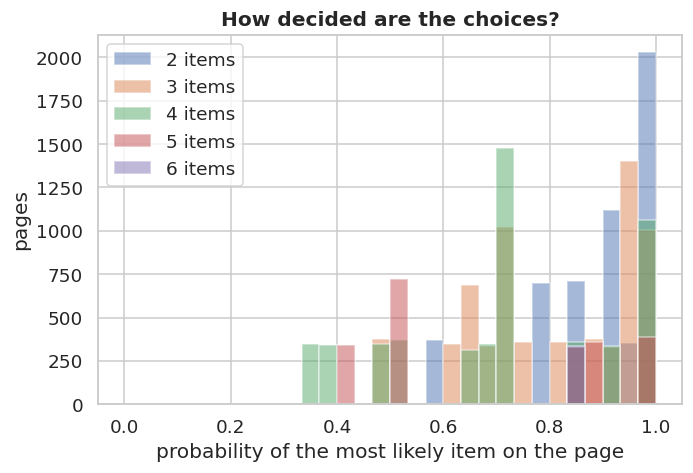

In [6]:
def sample_choices(probs, rng):
    """For each page (one row of probs), pick ONE item with those probabilities:
    a weighted die roll per page."""
    n_pages, n_items = probs.shape
    return np.array([rng.choice(n_items, p=probs[i]) for i in range(n_pages)])


rng = np.random.default_rng(2)

# check 1: on ONE fixed page, do sampled choices reproduce the probabilities?
page = [0, 1, 3]
p_page = page_probs_fast(U_true, np.array([to_mask(page, N_ITEMS)]))
picks = sample_choices(np.repeat(p_page, 20000, axis=0), rng)
observed = np.bincount(picks, minlength=N_ITEMS) / len(picks)
print(f"page {page}")
print("theory  :", np.round(p_page[0], 4))
print("sampled :", np.round(observed, 4))

# check 2: how decided are the choices over the whole sample?
sample_probs = page_probs_fast(U_true, sample_masks)
sample_choice = sample_choices(sample_probs, rng)

assert sample_masks[np.arange(len(sample_masks)), sample_choice].all()
print("\nevery chosen item was on its page.")

top_prob = sample_probs.max(axis=1)
entropy = -(sample_probs * np.log(np.where(sample_probs > 0, sample_probs, 1.0))).sum(axis=1)

print(f"\n{'size':>5}{'pages':>8}{'avg P(top item)':>17}{'pages with top > 0.9':>22}{'entropy, % of max':>19}")
for k in sizes:
    sel = sample_sizes == k
    print(f"{k:>5}{int(sel.sum()):>8}{top_prob[sel].mean():>17.3f}"
          f"{100 * (top_prob[sel] > 0.9).mean():>21.1f}%"
          f"{100 * (entropy[sel] / np.log(k)).mean():>18.1f}%")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for k in sizes:
    ax.hist(top_prob[sample_sizes == k], bins=30, range=(0, 1), alpha=0.5, label=f"{k} items")
ax.set_xlabel("probability of the most likely item on the page")
ax.set_ylabel("pages")
ax.set_title("How decided are the choices?")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
def make_dataset(U, all_pages, n_sessions, seed):
    """Build a dataset of n_sessions sessions.
      1. pick a random page for each session (every possible page equally likely)
      2. work out the probabilities of the items on that page
      3. pick one item with those probabilities
    Returns masks (which items were on each page), choices (the item picked), probs."""
    rng = np.random.default_rng(seed)
    masks = all_pages[rng.integers(0, len(all_pages), size=n_sessions)]
    probs = page_probs_fast(U, masks)
    choices = sample_choices(probs, rng)
    return masks, choices, probs


m1, c1, _ = make_dataset(U_true, ALL_PAGES, 1000, seed=7)
m2, c2, _ = make_dataset(U_true, ALL_PAGES, 1000, seed=7)
m3, c3, _ = make_dataset(U_true, ALL_PAGES, 1000, seed=8)

print("same seed -> identical data      :", np.array_equal(m1, m2) and np.array_equal(c1, c2))
print("different seed -> different data :", not np.array_equal(c1, c3))
assert m1[np.arange(len(m1)), c1].all()
print("every chosen item was on its page.")

print("\nshapes: masks", m1.shape, "| choices", c1.shape)
print("\nfirst 5 sessions:")
for i in range(5):
    page = np.flatnonzero(m1[i]).tolist()
    print(f"  page {page} -> chosen item {c1[i]}")

same seed -> identical data      : True
different seed -> different data : True
every chosen item was on its page.

shapes: masks (1000, 6) | choices (1000,)

first 5 sessions:
  page [0, 1, 3, 4, 5] -> chosen item 4
  page [0, 1, 2, 3] -> chosen item 1
  page [0, 1, 3, 4] -> chosen item 4
  page [0, 1, 2, 3, 5] -> chosen item 5
  page [2, 3, 5] -> chosen item 5


In [8]:
picked_top = (sample_choice == sample_probs.argmax(axis=1))   # True when the favourite was the item actually picked

print(f"{'size':>5}{'average P(favourite)':>22}{'favourite actually picked':>27}")
for k in sizes:
    sel = sample_sizes == k
    print(f"{k:>5}{top_prob[sel].mean():>22.3f}{picked_top[sel].mean():>27.3f}")

 size  average P(favourite)  favourite actually picked
    2                 0.899                      0.902
    3                 0.808                      0.807
    4                 0.710                      0.710
    5                 0.697                      0.697
    6                 0.836                      0.834


In [9]:
U_b = U_toy.copy()
U_b[0, 1] += 5
U_b[1, 0] += 5

print("original matrix:")
_ = show(U_toy, [0, 1])
_ = show(U_toy, [0, 1, 2])
print("\nafter adding 5 to both u_01 and u_10:")
_ = show(U_b, [0, 1])
_ = show(U_b, [0, 1, 2])

original matrix:
page [0, 1]: scores {0: 1.0, 1: 0.0}   probabilities {0: 0.7311, 1: 0.2689}
page [0, 1, 2]: scores {0: 1.0, 1: 2.0, 2: 3.0}   probabilities {0: 0.09, 1: 0.2447, 2: 0.6652}

after adding 5 to both u_01 and u_10:
page [0, 1]: scores {0: 6.0, 1: 5.0}   probabilities {0: 0.7311, 1: 0.2689}
page [0, 1, 2]: scores {0: 6.0, 1: 7.0, 2: 3.0}   probabilities {0: 0.2654, 1: 0.7214, 2: 0.0132}


In [11]:
def offdiag_index(n_items):
    """Give each off-diagonal entry u_ab (a != b) its own column number: idx[a, b]."""
    idx = -np.ones((n_items, n_items), dtype=int)
    k = 0
    for a in range(n_items):
        for b in range(n_items):
            if a != b:
                idx[a, b] = k
                k += 1
    return idx


def design_matrix(masks, n_items):
    """One row ('equation') per (page C, item x on C).
    The coefficient of u_ab is |C|-1 if a == x (x's own entries), -1 for the other entries on the page,
    and 0 for entries of items not on the page."""
    idx = offdiag_index(n_items)
    rows = []
    for m in masks:
        page = np.flatnonzero(m)
        size = len(page)
        for x in page:
            row = np.zeros(n_items * (n_items - 1))
            for a in page:
                for b in page:
                    if a != b:
                        row[idx[a, b]] = size * (a == x) - 1
            rows.append(row)
    return np.array(rows)


# ---- check 1: a 3-item world you can read by hand ----
n3 = 3
labels = [f"u{a}{b}" for a in range(n3) for b in range(n3) if a != b]
print("columns:", labels)
G_pair = design_matrix(np.array([to_mask([0, 1], n3)]), n3)
G_triple = design_matrix(np.array([to_mask([0, 1, 2], n3)]), n3)
print("page {0,1}   row for item 0:", G_pair[0].astype(int))
print("page {0,1}   row for item 1:", G_pair[1].astype(int))
print("page {0,1,2} row for item 0:", G_triple[0].astype(int))
assert np.array_equal(G_pair[0], [1, 0, -1, 0, 0, 0])
assert np.array_equal(G_pair[1], [-1, 0, 1, 0, 0, 0])
assert np.array_equal(G_triple[0], [2, 2, -1, -1, -1, -1])
print("hand-checked rows match.")

# ---- check 2: on your real U, each equation must equal what the probabilities say ----
u_vec = np.array([U_true[a, b] for a in range(N_ITEMS) for b in range(N_ITEMS) if a != b])
for page in [[0, 1], [0, 1, 3], [0, 3, 4], [1, 2, 3, 5], [0, 1, 2, 3, 4, 5]]:
    mask = to_mask(page, N_ITEMS)
    G_page = design_matrix(np.array([mask]), N_ITEMS)
    p = page_probs_fast(U_true, np.array([mask]))[0][page]
    expected = len(page) * (np.log(p) - np.log(p).mean())
    assert np.allclose(G_page @ u_vec, expected)
print("each equation matches the log-probabilities on 5 pages of your U.")

columns: ['u01', 'u02', 'u10', 'u12', 'u20', 'u21']
page {0,1}   row for item 0: [ 1  0 -1  0  0  0]
page {0,1}   row for item 1: [-1  0  1  0  0  0]
page {0,1,2} row for item 0: [ 2  2 -1 -1 -1 -1]
hand-checked rows match.
each equation matches the log-probabilities on 5 pages of your U.


In [12]:
MAX_FACTS = N_ITEMS * (N_ITEMS - 1) - 1
G_all = design_matrix(ALL_PAGES, N_ITEMS)
print("rows written down for all 57 pages:", G_all.shape[0])
print("every row adds up to zero (adding one number to all of U changes nothing):",
      bool(np.allclose(G_all.sum(axis=1), 0)))
print("most independent facts that can ever be learned:", MAX_FACTS, "\n")

options = [
    ("pairs only",              [2]),
    ("triples only",            [3]),
    ("4-item pages only",       [4]),
    ("5-item pages only",       [5]),
    ("the one 6-item page",     [6]),
    ("pairs + triples",         [2, 3]),
    ("triples + 4-item pages",  [3, 4]),
    ("pairs + the 6-item page", [2, 6]),
    ("all page sizes",          [2, 3, 4, 5, 6]),
]

print(f"{'pages used':<26}{'pages':>7}{'rows':>7}{'independent facts':>19}   all 29 learned?")
for name, sizes_used in options:
    masks_sel = ALL_PAGES[np.isin(ALL_SIZES, sizes_used)]
    G = design_matrix(masks_sel, N_ITEMS)
    r = int(np.linalg.matrix_rank(G))
    print(f"{name:<26}{len(masks_sel):>7}{G.shape[0]:>7}{r:>19}   {'YES' if r == MAX_FACTS else 'no'}")

rows written down for all 57 pages: 186
every row adds up to zero (adding one number to all of U changes nothing): True
most independent facts that can ever be learned: 29 

pages used                  pages   rows  independent facts   all 29 learned?
pairs only                     15     30                 15   no
triples only                   20     60                 24   no
4-item pages only              15     60                 24   no
5-item pages only               6     30                 24   no
the one 6-item page             1      6                  5   no
pairs + triples                35     90                 29   YES
triples + 4-item pages         35    120                 29   YES
pairs + the 6-item page        16     36                 20   no
all page sizes                 57    186                 29   YES


In [13]:
def independent_facts_for_pages(masks):
    """Number of non-repeat facts that these pages could reveal."""
    return int(np.linalg.matrix_rank(design_matrix(masks, N_ITEMS)))


rng = np.random.default_rng(10)
print(f"{'sessions':>9}{'distinct pages seen (avg, of 57)':>35}{'runs that reach all 29 facts':>32}")
for m in [10, 20, 40, 80, 160, 320, 1000]:
    reached, distinct = 0, []
    for rep in range(20):
        idx = rng.integers(0, len(ALL_PAGES), size=m)
        uniq = np.unique(idx)
        distinct.append(len(uniq))
        if independent_facts_for_pages(ALL_PAGES[uniq]) == MAX_FACTS:
            reached += 1
    print(f"{m:>9}{np.mean(distinct):>35.1f}{reached:>29}/20")

 sessions   distinct pages seen (avg, of 57)    runs that reach all 29 facts
       10                                9.1                            0/20
       20                               16.4                            8/20
       40                               29.2                           20/20
       80                               42.9                           20/20
      160                               53.7                           20/20
      320                               56.9                           20/20
     1000                               57.0                           20/20


In [14]:
def cdm_nll(U, masks, choices):
    """Average 'surprise' (negative log-likelihood) of the choices that were actually made,
    if the matrix U were the guess. Lower = the guess explains the data better."""
    U0 = U - torch.diag(torch.diag(U))                        # the diagonal is never used
    scores = masks @ U0.T                                     # scores[p, x] = sum over z on page p of U[x, z]
    scores = scores.masked_fill(masks == 0, float("-inf"))    # items not on the page cannot be chosen
    log_probs = torch.log_softmax(scores, dim=1)
    return -log_probs[torch.arange(len(choices)), choices].mean()


masks_d, choices_d, _ = make_dataset(U_true, ALL_PAGES, 20000, seed=11)
masks_t = torch.tensor(masks_d, dtype=torch.float64)
choices_t = torch.tensor(choices_d, dtype=torch.long)

rng = np.random.default_rng(3)
off = ~np.eye(N_ITEMS, dtype=bool)
guesses = {
    "the true U": U_true,
    "true U with 5 added to every entry": U_true + 5.0,
    "all zeros (every item equal)": np.zeros((N_ITEMS, N_ITEMS)),
    "true U with all signs flipped": -U_true,
    "a random matrix of the same size": rng.normal(0, U_true[off].std(), size=(N_ITEMS, N_ITEMS)),
}

print(f"{'guess':<40}{'average surprise':>18}")
for name, G in guesses.items():
    val = cdm_nll(torch.tensor(G, dtype=torch.float64), masks_t, choices_t).item()
    print(f"{name:<40}{val:>18.4f}")

sizes_d = masks_d.sum(axis=1)
print(f"\nfor reference, the average of ln(page size) over these sessions: {np.log(sizes_d).mean():.4f}")

guess                                     average surprise
the true U                                          0.4847
true U with 5 added to every entry                  0.4847
all zeros (every item equal)                        1.1348
true U with all signs flipped                       5.3138
a random matrix of the same size                    2.7766

for reference, the average of ln(page size) over these sessions: 1.1348


In [15]:
def gauge_fix(U):
    """Remove the 'add one number to every entry' freedom so two matrices can be compared:
    off-diagonal entries get average zero, the (unused) diagonal is set to zero."""
    n = U.shape[0]
    off = ~np.eye(n, dtype=bool)
    V = np.zeros_like(U, dtype=float)
    V[off] = U[off] - U[off].mean()
    return V


def fit_cdm(masks, choices, n_items, steps=3000, lr=0.05, verbose=True):
    """Find the matrix U that makes the observed choices least surprising (maximum likelihood).
    Starts from all zeros (every item equal) and repeatedly nudges U to lower the surprise."""
    masks_t = torch.tensor(masks, dtype=torch.float64)
    choices_t = torch.tensor(choices, dtype=torch.long)
    U = torch.zeros(n_items, n_items, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([U], lr=lr)
    history = []
    for step in range(steps):
        opt.zero_grad()
        loss = cdm_nll(U, masks_t, choices_t)
        loss.backward()
        opt.step()
        history.append(loss.item())
        if verbose and (step % 500 == 0 or step == steps - 1):
            print(f"step {step:>5}: average surprise = {loss.item():.4f}")
    return U.detach().numpy(), history


U_hat, history = fit_cdm(masks_d, choices_d, N_ITEMS)

true_nll = cdm_nll(torch.tensor(U_true, dtype=torch.float64),
                   torch.tensor(masks_d, dtype=torch.float64),
                   torch.tensor(choices_d, dtype=torch.long)).item()
err = float(np.sum((gauge_fix(U_hat) - gauge_fix(U_true)) ** 2))
err_zero = float(np.sum(gauge_fix(U_true) ** 2))

print(f"\nsurprise of the fitted U : {history[-1]:.4f}   (true U on the same data: {true_nll:.4f})")
print(f"squared error of the fit : {err:.3f}   (for scale, a guess of all zeros would have error {err_zero:.1f})")
print("\ntrue U (shift removed):");   print(np.round(gauge_fix(U_true), 2))
print("\nfitted U (shift removed):"); print(np.round(gauge_fix(U_hat), 2))

step     0: average surprise = 1.1348
step   500: average surprise = 0.4840
step  1000: average surprise = 0.4838
step  1500: average surprise = 0.4837
step  2000: average surprise = 0.4837
step  2500: average surprise = 0.4837
step  2999: average surprise = 0.4837

surprise of the fitted U : 0.4837   (true U on the same data: 0.4847)
squared error of the fit : 1.232   (for scale, a guess of all zeros would have error 137.1)

true U (shift removed):
[[ 0.   -0.17  2.51 -0.83 -1.07 -3.25]
 [ 3.48  0.   -0.18 -3.24  0.1  -1.61]
 [ 0.28  0.18  0.   -1.42  3.21  1.14]
 [-3.44  2.2  -0.17  0.    1.02 -0.6 ]
 [ 2.69  1.87 -0.83 -1.47  0.    2.78]
 [ 0.03  2.47 -0.67  0.74 -5.73  0.  ]]

fitted U (shift removed):
[[ 0.   -0.38  2.32 -0.73 -0.96 -2.94]
 [ 3.59  0.   -0.52 -3.38 -0.04 -1.68]
 [ 0.27 -0.06  0.   -1.43  3.13  1.35]
 [-3.29  1.93 -0.27  0.    1.09 -0.32]
 [ 2.73  1.64 -1.07 -1.46  0.    3.11]
 [ 0.01  2.27 -0.52  0.81 -5.21  0.  ]]


dataset 0 saved (95s so far)
dataset 1 saved (190s so far)
dataset 2 saved (287s so far)
dataset 3 saved (385s so far)
dataset 4 saved (481s so far)
dataset 5 saved (578s so far)
dataset 6 saved (675s so far)
dataset 7 saved (772s so far)
dataset 8 saved (870s so far)
dataset 9 saved (967s so far)
          median    min     max
sessions                       
1000       8.081  5.325  18.970
2000       4.684  2.015   7.815
5000       1.900  1.151   6.634
10000      1.065  0.442   3.539
20000      0.762  0.188   1.427
50000      0.180  0.090   0.365
100000     0.110  0.028   0.228

log-log slope of the median error: -0.94   (the paper's guide line has slope -1)


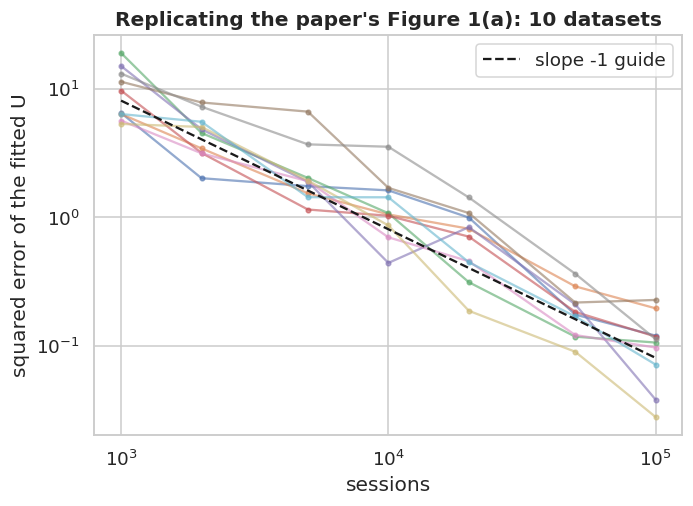

In [16]:
FIG1A_CSV = os.path.join(OUT_DIR, "cdm_fig1a_replication.csv")
sizes_m = [1000, 2000, 5000, 10000, 20000, 50000, 100000]
N_DATASETS = 10

done = pd.read_csv(FIG1A_CSV) if os.path.exists(FIG1A_CSV) else pd.DataFrame(columns=["dataset", "sessions", "sq_error"])
t0 = time.time()
for d in range(N_DATASETS):
    if d in set(done.dataset):
        continue
    masks_big, choices_big, _ = make_dataset(U_true, ALL_PAGES, max(sizes_m), seed=1000 + d)
    rows = []
    for m in sizes_m:
        U_hat_m, _ = fit_cdm(masks_big[:m], choices_big[:m], N_ITEMS, steps=2000, verbose=False)
        err_m = float(np.sum((gauge_fix(U_hat_m) - gauge_fix(U_true)) ** 2))
        rows.append(dict(dataset=d, sessions=m, sq_error=err_m))
    pd.DataFrame(rows).to_csv(FIG1A_CSV, mode="a", header=not os.path.exists(FIG1A_CSV), index=False)
    print(f"dataset {d} saved ({time.time() - t0:.0f}s so far)")

fig1a = pd.read_csv(FIG1A_CSV)
summary = fig1a.groupby("sessions").sq_error.agg(["median", "min", "max"])
print(summary.round(3).to_string())

slope = np.polyfit(np.log(summary.index.values), np.log(summary["median"].values), 1)[0]
print(f"\nlog-log slope of the median error: {slope:.2f}   (the paper's guide line has slope -1)")

fig, ax = plt.subplots(figsize=(6.5, 4.8))
for d, g in fig1a.groupby("dataset"):
    ax.plot(g.sessions, g.sq_error, alpha=0.6, marker="o", ms=3)
guide = summary["median"].iloc[0] * summary.index[0] / summary.index.values
ax.plot(summary.index, guide, "k--", label="slope -1 guide")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("sessions")
ax.set_ylabel("squared error of the fitted U")
ax.set_title("Replicating the paper's Figure 1(a): 10 datasets")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
def cdm_scores(U, masks):
    """Raw CDM scores: scores[p, x] = sum over z on page p of U[x, z]. (Only items on the page are meaningful.)"""
    U0 = U - np.diag(np.diag(U))
    return masks @ U0.T


def probe_cdm(score_fn, all_pages, n_items):
    """Read a matrix U_hat out of ANY model that maps pages to scores.
    score_fn(masks) -> array (n_pages, n_items) of scores for the items on each page.
    For every pair (a, b): look at all pages containing both, regress the gap (score of a - score of b)
    on which OTHER items are present, then combine all the answers into one matrix."""
    scores_all = score_fn(all_pages)
    idx = offdiag_index(n_items)
    n_unknown = n_items * (n_items - 1)
    A_rows, y = [], []
    for a in range(n_items):
        for b in range(a + 1, n_items):
            sel = np.flatnonzero((all_pages[:, a] > 0) & (all_pages[:, b] > 0))
            others = [z for z in range(n_items) if z not in (a, b)]
            gap = scores_all[sel, a] - scores_all[sel, b]
            design = np.column_stack([np.ones(len(sel)), all_pages[np.ix_(sel, others)]])
            coef, *_ = np.linalg.lstsq(design, gap, rcond=None)
            eq = np.zeros(n_unknown); eq[idx[a, b]] = 1; eq[idx[b, a]] = -1       # intercept = u_ab - u_ba
            A_rows.append(eq); y.append(coef[0])
            for i, z in enumerate(others):                                        # slope on z = u_az - u_bz
                eq = np.zeros(n_unknown); eq[idx[a, z]] = 1; eq[idx[b, z]] = -1
                A_rows.append(eq); y.append(coef[1 + i])
    sol, *_ = np.linalg.lstsq(np.array(A_rows), np.array(y), rcond=None)
    U_read = np.zeros((n_items, n_items))
    for a in range(n_items):
        for b in range(n_items):
            if a != b:
                U_read[a, b] = sol[idx[a, b]]
    return gauge_fix(U_read)


# ---- check 1: feed it the TRUE rulebook ----
U_read_true = probe_cdm(lambda m: cdm_scores(U_true, m), ALL_PAGES, N_ITEMS)
print("probe on the true U : largest difference from the truth =",
      f"{np.abs(U_read_true - gauge_fix(U_true)).max():.2e}")

# ---- check 2: feed it the matrix we FITTED in Cell 12 ----
U_read_fit = probe_cdm(lambda m: cdm_scores(U_hat, m), ALL_PAGES, N_ITEMS)
print("probe on fitted U   : largest difference from the fitted matrix =",
      f"{np.abs(U_read_fit - gauge_fix(U_hat)).max():.2e}")
print("squared error of what the probe read vs the truth:",
      f"{np.sum((U_read_fit - gauge_fix(U_true)) ** 2):.3f}   (Cell 12 gave 1.232)")

probe on the true U : largest difference from the truth = 7.11e-15
probe on fitted U   : largest difference from the fitted matrix = 7.11e-15
squared error of what the probe read vs the truth: 1.232   (Cell 12 gave 1.232)


In [18]:
def context_part(U):
    """Split off what a plain one-score-per-item model (MNL) can express.
    Each column's average (over its off-diagonal entries) is that item's popularity, with a minus sign.
    Subtracting it leaves the pure item-on-item pushes: the context effect."""
    n = U.shape[0]
    C = np.zeros((n, n))
    for z in range(n):
        rows = [x for x in range(n) if x != z]
        C[rows, z] = U[rows, z] - U[rows, z].mean()
    return C


def cdm_recovery_metrics(U_hat, U_true):
    """Score a recovered matrix on the CONTEXT part only (what MNL cannot express).
    cosine: right direction?  scale_ratio: right strength?  rel_frob: overall error (0 perfect, 1 = found nothing).
    paper_sq_error: the paper's own measure on the full matrix (shift removed), for comparison."""
    n = U_true.shape[0]
    off = ~np.eye(n, dtype=bool)
    a, b = context_part(U_hat)[off], context_part(U_true)[off]
    return dict(
        cosine=float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)),
        rel_frob=float(np.linalg.norm(a - b) / np.linalg.norm(b)),
        scale_ratio=float(np.linalg.norm(a) / np.linalg.norm(b)),
        paper_sq_error=float(np.sum((gauge_fix(U_hat) - gauge_fix(U_true)) ** 2)),
    )


# ---- a plain MNL model: every item has ONE score, whatever else is on the page ----
popularity = np.array([-U_true[[x for x in range(N_ITEMS) if x != z], z].mean() for z in range(N_ITEMS)])
mnl_scores = lambda masks: np.tile(popularity, (len(masks), 1))

U_read_mnl = probe_cdm(mnl_scores, ALL_PAGES, N_ITEMS)
spread = max(np.ptp(U_read_mnl[[x for x in range(N_ITEMS) if x != z], z]) for z in range(N_ITEMS))
print(f"MNL read out by the probe: largest spread inside any column = {spread:.1e}   (0 means every column is constant)")

# ---- calibration table: three models whose answer we already know ----
cases = {
    "true U (should be perfect)":          probe_cdm(lambda m: cdm_scores(U_true, m), ALL_PAGES, N_ITEMS),
    "plain MNL (must find no context)":    U_read_mnl,
    "fitted U from Cell 12":               probe_cdm(lambda m: cdm_scores(U_hat, m), ALL_PAGES, N_ITEMS),
}
print(f"\n{'model':<36}{'cosine':>9}{'rel_frob':>10}{'scale':>8}{'paper sq. error':>17}")
for name, U_read in cases.items():
    r = cdm_recovery_metrics(U_read, U_true)
    print(f"{name:<36}{r['cosine']:>9.4f}{r['rel_frob']:>10.4f}{r['scale_ratio']:>8.4f}{r['paper_sq_error']:>17.3f}")

MNL read out by the probe: largest spread inside any column = 3.8e-15   (0 means every column is constant)

model                                  cosine  rel_frob   scale  paper sq. error
true U (should be perfect)             1.0000    0.0000  1.0000            0.000
plain MNL (must find no context)      -0.0020    1.0000  0.0000          117.115
fitted U from Cell 12                  0.9977    0.0699  0.9800            1.232


In [20]:
import torch.nn as nn
class MNLControl(nn.Module):
    """One score per item, whatever else is on the page: a model that cannot see context at all."""
    def __init__(self, n_items):
        super().__init__()
        self.v = nn.Parameter(torch.zeros(n_items, dtype=torch.float64))

    def forward(self, masks):                       # masks: (n_pages, n_items) of 0/1
        return self.v.unsqueeze(0).expand(masks.shape[0], -1)


def nll_from_scores(scores, masks, choices):
    """Average surprise of the picks, for ANY model that outputs one score per item."""
    scores = scores.masked_fill(masks == 0, float("-inf"))      # items not on the page cannot be chosen
    log_probs = torch.log_softmax(scores, dim=1)
    return -log_probs[torch.arange(len(choices)), choices].mean()


def train_choice_model(model, masks, choices, steps=1500, lr=0.05, verbose=True):
    """Train any model: nudge its parameters to make the observed picks least surprising."""
    masks_t = torch.tensor(masks, dtype=torch.float64)
    choices_t = torch.tensor(choices, dtype=torch.long)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for step in range(steps):
        model.train()
        opt.zero_grad()
        loss = nll_from_scores(model(masks_t), masks_t, choices_t)
        loss.backward()
        opt.step()
        history.append(loss.item())
        if verbose and (step % 500 == 0 or step == steps - 1):
            print(f"step {step:>5}: average surprise = {loss.item():.4f}")
    return history


def score_fn_from_model(model):
    """Wrap a trained model so the probe can read it: pages in, scores out (always in evaluation mode)."""
    def f(masks):
        model.eval()
        with torch.no_grad():
            return model(torch.tensor(masks, dtype=torch.float64)).numpy()
    return f


mnl = MNLControl(N_ITEMS)
hist_mnl = train_choice_model(mnl, masks_d, choices_d)

print("\naverage surprise on these 20,000 sessions:")
print("  know nothing (all zeros)  : 1.1348")
print(f"  trained MNL (this cell)   : {hist_mnl[-1]:.4f}")
print("  true U / fitted CDM       : 0.4847 / 0.4837")

v_learned = mnl.v.detach().numpy().copy()
v_learned -= v_learned.mean()
print("\npopularity learned by MNL (centred):", np.round(v_learned, 2))
print("popularity read from true U (centred):", np.round(popularity - popularity.mean(), 2))

U_read_mnl2 = probe_cdm(score_fn_from_model(mnl), ALL_PAGES, N_ITEMS)
spread2 = max(np.ptp(U_read_mnl2[[x for x in range(N_ITEMS) if x != z], z]) for z in range(N_ITEMS))
r = cdm_recovery_metrics(U_read_mnl2, U_true)
print(f"\nprobe on the trained MNL: column spread = {spread2:.1e}, cosine = {r['cosine']:.4f}, "
      f"scale = {r['scale_ratio']:.4f}, rel_frob = {r['rel_frob']:.4f}")

step     0: average surprise = 1.1348
step   500: average surprise = 0.9960
step  1000: average surprise = 0.9960
step  1499: average surprise = 0.9960

average surprise on these 20,000 sessions:
  know nothing (all zeros)  : 1.1348
  trained MNL (this cell)   : 0.9960
  true U / fitted CDM       : 0.4847 / 0.4837

popularity learned by MNL (centred): [-0.72 -0.8   0.63 -0.14  0.9   0.15]
popularity read from true U (centred): [-0.61 -1.31 -0.13  1.24  0.5   0.31]

probe on the trained MNL: column spread = 4.1e-15, cosine = -0.0100, scale = 0.0000, rel_frob = 1.0000


In [21]:
N10 = 10
PAGES10, SIZES10 = all_pages(N10)
print("possible pages at 10 items:", len(PAGES10))
sizes10, counts10 = np.unique(SIZES10, return_counts=True)
print("pages per size:", dict(zip(sizes10.tolist(), counts10.tolist())))

off10 = ~np.eye(N10, dtype=bool)
print(f"\n{'rank':>5}{'entry spread':>14}{'avg P(top item)':>17}{'pages with top > 0.9':>22}"
      f"{'know-nothing':>14}{'true-U surprise':>17}")
for r in [2, 3, 5, 10]:
    U10, _, _ = make_cdm_truth(N10, r, seed=12345)
    probs10 = page_probs_fast(U10, PAGES10)                     # probabilities on EVERY possible page
    top = probs10.max(axis=1)
    ent = -(probs10 * np.log(np.where(probs10 > 0, probs10, 1.0))).sum(axis=1)
    print(f"{r:>5}{U10[off10].std():>14.2f}{top.mean():>17.3f}{100 * (top > 0.9).mean():>21.1f}%"
          f"{np.log(SIZES10).mean():>14.3f}{ent.mean():>17.3f}")

possible pages at 10 items: 1013
pages per size: {2: 45, 3: 120, 4: 210, 5: 252, 6: 210, 7: 120, 8: 45, 9: 10, 10: 1}

 rank  entry spread  avg P(top item)  pages with top > 0.9  know-nothing  true-U surprise
    2          1.71            0.744                 30.8%         1.567            0.661
    3          1.74            0.779                 39.9%         1.567            0.563
    5          1.96            0.809                 42.0%         1.567            0.504
   10          3.05            0.907                 71.1%         1.567            0.232


In [22]:
N_DRAWS = 30
print(f"{'rank':>5}{'avg P(top item)':>22}{'range':>16}{'pages with top > 0.9 (%)':>28}{'true-U surprise':>22}")
for r in [2, 3, 5]:
    tops, shares, surprises = [], [], []
    for s in range(N_DRAWS):
        U10, _, _ = make_cdm_truth(N10, r, seed=s)
        probs10 = page_probs_fast(U10, PAGES10)
        top = probs10.max(axis=1)
        ent = -(probs10 * np.log(np.where(probs10 > 0, probs10, 1.0))).sum(axis=1)
        tops.append(top.mean())
        shares.append(100 * (top > 0.9).mean())
        surprises.append(ent.mean())
    print(f"{r:>5}{np.mean(tops):>14.3f} ± {np.std(tops):.3f}"
          f"{min(tops):>9.3f}-{max(tops):.3f}"
          f"{np.mean(shares):>16.1f} ± {np.std(shares):.1f}"
          f"{np.mean(surprises):>14.3f} ± {np.std(surprises):.3f}")

 rank       avg P(top item)           range    pages with top > 0.9 (%)       true-U surprise
    2         0.690 ± 0.090    0.506-0.841            23.9 ± 14.7         0.772 ± 0.208
    3         0.761 ± 0.070    0.645-0.906            35.8 ± 16.3         0.602 ± 0.171
    5         0.799 ± 0.049    0.717-0.903            43.4 ± 12.2         0.505 ± 0.124


In [23]:
TARGET_RMS = np.sqrt(3.0)      # the size the paper's recipe gives on average at rank 3 (entry variance = rank)


def pin_size(U, target_rms=TARGET_RMS):
    """Multiply U by one number so that its size (root-mean-square of the off-diagonal entries,
    with the 'add one number to everything' shift removed) equals target_rms.
    Same CDM, same rank, same structure: only the loudness is fixed."""
    n = U.shape[0]
    off = ~np.eye(n, dtype=bool)
    rms = np.sqrt(np.mean(gauge_fix(U)[off] ** 2))
    return U * (target_rms / rms)


def decidedness(U, masks):
    probs = page_probs_fast(U, masks)
    top = probs.max(axis=1)
    ent = -(probs * np.log(np.where(probs > 0, probs, 1.0))).sum(axis=1)
    return top.mean(), 100 * (top > 0.9).mean(), ent.mean()


N_DRAWS = 30
print(f"{'rank':>5}{'version':>10}{'avg P(top item)':>22}{'range':>16}{'pages top > 0.9 (%)':>24}{'true-U surprise':>22}")
for r in [2, 3, 5]:
    for version in ["raw", "pinned"]:
        vals = []
        for s in range(N_DRAWS):
            U10, _, _ = make_cdm_truth(N10, r, seed=s)
            if version == "pinned":
                U10 = pin_size(U10)
            vals.append(decidedness(U10, PAGES10))
        v = np.array(vals)
        print(f"{r:>5}{version:>10}{v[:, 0].mean():>14.3f} ± {v[:, 0].std():.3f}"
              f"{v[:, 0].min():>9.3f}-{v[:, 0].max():.3f}"
              f"{v[:, 1].mean():>14.1f} ± {v[:, 1].std():.1f}"
              f"{v[:, 2].mean():>14.3f} ± {v[:, 2].std():.3f}")

 rank   version       avg P(top item)           range     pages top > 0.9 (%)       true-U surprise
    2       raw         0.690 ± 0.090    0.506-0.841          23.9 ± 14.7         0.772 ± 0.208
    2    pinned         0.746 ± 0.059    0.634-0.897          32.8 ± 12.6         0.639 ± 0.142
    3       raw         0.761 ± 0.070    0.645-0.906          35.8 ± 16.3         0.602 ± 0.171
    3    pinned         0.773 ± 0.047    0.686-0.881          37.5 ± 11.3         0.572 ± 0.118
    5       raw         0.799 ± 0.049    0.717-0.903          43.4 ± 12.2         0.505 ± 0.124
    5    pinned         0.759 ± 0.042    0.691-0.867          34.2 ± 9.8         0.608 ± 0.104


seed 101 saved (188s so far)
seed 202 saved (368s so far)
seed 303 saved (547s so far)
seed 404 saved (731s so far)
seed 505 saved (900s so far)
         ctx_rel_frob        ctx_scale        paper_sq_error         fit_gap       
                 mean    std      mean    std           mean     std    mean    std
sessions                                                                           
2000            0.243  0.160     1.105  0.067         35.730  49.088  -0.020  0.003
5000            0.137  0.051     1.045  0.020          8.285   4.305  -0.008  0.001
10000           0.080  0.018     1.015  0.011          3.267   1.319  -0.004  0.001
20000           0.057  0.015     1.007  0.014          2.127   1.194  -0.002  0.000
50000           0.045  0.029     1.007  0.014          1.205   1.104  -0.001  0.000
100000          0.026  0.008     1.001  0.005          0.442   0.227  -0.000  0.000


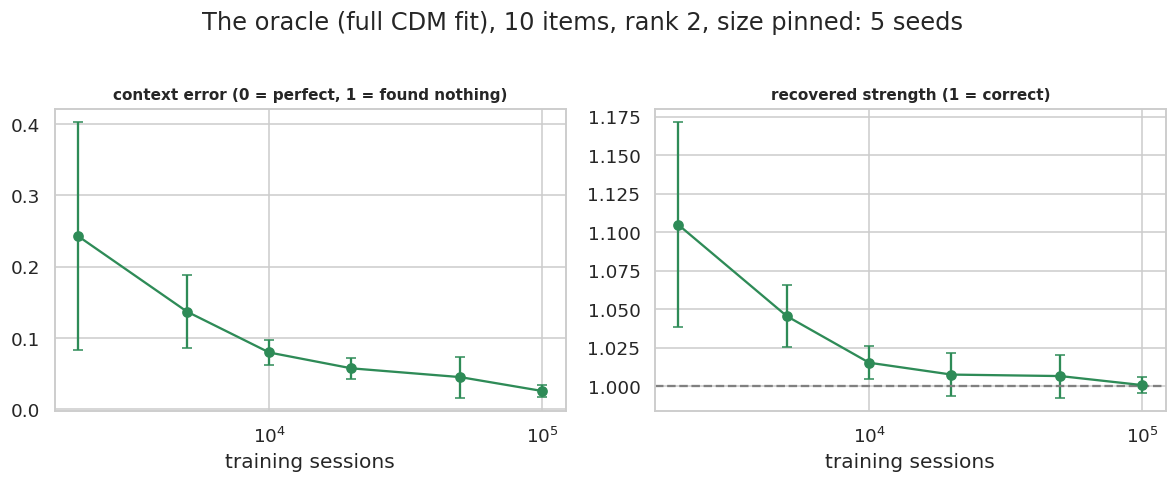

In [24]:
ORACLE_CSV = os.path.join(OUT_DIR, "cdm_oracle_size_curve_n10.csv")
N_ITEMS10, RANK10 = 10, 2
SIZES10_M = [2000, 5000, 10000, 20000, 50000, 100000]
SEEDS10 = [101, 202, 303, 404, 505]

done = pd.read_csv(ORACLE_CSV) if os.path.exists(ORACLE_CSV) else pd.DataFrame(columns=["seed"])
t0 = time.time()
for s in SEEDS10:
    if s in set(done.seed):
        continue
    U_s = pin_size(make_cdm_truth(N_ITEMS10, RANK10, seed=s)[0])
    masks_big, choices_big, _ = make_dataset(U_s, PAGES10, max(SIZES10_M), seed=s + 1)
    rows = []
    for m in SIZES10_M:
        U_fit, hist = fit_cdm(masks_big[:m], choices_big[:m], N_ITEMS10, steps=3000, verbose=False)
        true_nll = cdm_nll(torch.tensor(U_s, dtype=torch.float64),
                           torch.tensor(masks_big[:m], dtype=torch.float64),
                           torch.tensor(choices_big[:m], dtype=torch.long)).item()
        r = cdm_recovery_metrics(U_fit, U_s)
        rows.append(dict(seed=s, sessions=m, ctx_rel_frob=r["rel_frob"], ctx_cosine=r["cosine"],
                         ctx_scale=r["scale_ratio"], paper_sq_error=r["paper_sq_error"],
                         fit_nll=hist[-1], true_nll=true_nll))
    pd.DataFrame(rows).to_csv(ORACLE_CSV, mode="a", header=not os.path.exists(ORACLE_CSV), index=False)
    print(f"seed {s} saved ({time.time() - t0:.0f}s so far)")

res = pd.read_csv(ORACLE_CSV)
res["fit_gap"] = res.fit_nll - res.true_nll
cols = ["ctx_rel_frob", "ctx_scale", "paper_sq_error", "fit_gap"]
summary = res.groupby("sessions")[cols].agg(["mean", "std"])
print(summary.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, col, title in [(axes[0], "ctx_rel_frob", "context error (0 = perfect, 1 = found nothing)"),
                       (axes[1], "ctx_scale", "recovered strength (1 = correct)")]:
    g = res.groupby("sessions")[col].agg(["mean", "std"]).reset_index()
    ax.errorbar(g.sessions, g["mean"], yerr=g["std"], marker="o", capsize=3, color="seagreen")
    ax.set_xscale("log")
    ax.set_xlabel("training sessions")
    ax.set_title(title, fontsize=10)
axes[1].axhline(1.0, color="gray", linestyle="--")
plt.suptitle("The oracle (full CDM fit), 10 items, rank 2, size pinned: 5 seeds", y=1.02)
plt.tight_layout()
plt.show()

In [25]:
def build_cdm_splits(U, all_pages, n_train, seed, holdout_frac=0.2, n_val=5000, n_eval=5000, n_shift=5000):
    """train / val / eval_in use only 'seen' pages; eval_shift uses only pages held out of everything else."""
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(all_pages))
    n_hold = int(round(holdout_frac * len(all_pages)))
    held, seen = perm[:n_hold], perm[n_hold:]

    def draw(page_ids, n, sd):
        r = np.random.default_rng(sd)
        masks = all_pages[r.choice(page_ids, size=n)]
        choices = sample_choices(page_probs_fast(U, masks), r)
        return dict(masks=masks, choices=choices)

    splits = dict(train=draw(seen, n_train, seed * 10 + 1), val=draw(seen, n_val, seed * 10 + 2),
                  eval_in=draw(seen, n_eval, seed * 10 + 3), eval_shift=draw(held, n_shift, seed * 10 + 4))
    return splits, seen, held


U_ref = pin_size(make_cdm_truth(N_ITEMS10, RANK10, seed=101)[0])
splits10, seen_ids, held_ids = build_cdm_splits(U_ref, PAGES10, n_train=20000, seed=101)

# check 1: no held-out page appears in train
rows_train = {row.tobytes() for row in splits10["train"]["masks"]}
rows_held = {row.tobytes() for row in PAGES10[held_ids]}
print("held-out pages:", len(held_ids), "| seen pages:", len(seen_ids),
      "| any held-out page in train?", len(rows_train & rows_held) > 0)

# check 2: do the seen pages still carry all the facts about U?
G_seen = design_matrix(PAGES10[seen_ids], N_ITEMS10)
print("independent facts in the seen pages:", int(np.linalg.matrix_rank(G_seen)), "(maximum possible: 89)")

# check 3: how hard is each split? (surprise of the TRUE U = the best any model can do)
print(f"\n{'split':<12}{'sessions':>9}{'distinct pages':>16}{'avg page size':>15}{'know-nothing':>14}{'true-U surprise':>17}")
for name, d in splits10.items():
    m_t = torch.tensor(d["masks"], dtype=torch.float64)
    c_t = torch.tensor(d["choices"], dtype=torch.long)
    true_s = cdm_nll(torch.tensor(U_ref, dtype=torch.float64), m_t, c_t).item()
    sizes_s = d["masks"].sum(axis=1)
    print(f"{name:<12}{len(d['masks']):>9}{len({r.tobytes() for r in d['masks']}):>16}"
          f"{sizes_s.mean():>15.2f}{np.log(sizes_s).mean():>14.3f}{true_s:>17.3f}")

held-out pages: 203 | seen pages: 810 | any held-out page in train? False
independent facts in the seen pages: 89 (maximum possible: 89)

split        sessions  distinct pages  avg page size  know-nothing  true-U surprise
train           20000             810           5.03         1.566            0.579
val              5000             809           5.04         1.566            0.576
eval_in          5000             808           5.04         1.567            0.573
eval_shift       5000             203           5.05         1.562            0.592


In [26]:
import copy


class CDMOracle(nn.Module):
    """The paper's CDM with a full n x n grid of pushes: the formula is built in, only the numbers are learned."""
    def __init__(self, n_items):
        super().__init__()
        self.U = nn.Parameter(torch.zeros(n_items, n_items, dtype=torch.float64))

    def forward(self, masks):
        U0 = self.U - torch.diag(torch.diag(self.U))        # the diagonal is never used
        return masks @ U0.T


def to_tensors(d):
    return torch.tensor(d["masks"], dtype=torch.float64), torch.tensor(d["choices"], dtype=torch.long)


def eval_nll_cdm(model, d):
    """Average surprise on one split, with the model in evaluation mode."""
    was_training = model.training
    model.eval()
    m_t, c_t = to_tensors(d)
    with torch.no_grad():
        loss = nll_from_scores(model(m_t), m_t, c_t).item()
    model.train(was_training)
    return loss


def train_with_early_stopping_cdm(model, splits, max_epochs=3000, lr=0.05, patience=200,
                                  verbose=True, print_every=500):
    """Train on 'train'; keep the weights of the epoch with the lowest surprise on 'val'; stop when
    'val' has not improved for `patience` epochs."""
    m_tr, c_tr = to_tensors(splits["train"])
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_val, best_state, best_epoch = float("inf"), None, 0
    train_hist, val_hist = [], []
    for epoch in range(max_epochs):
        model.train()
        opt.zero_grad()
        loss = nll_from_scores(model(m_tr), m_tr, c_tr)
        loss.backward()
        opt.step()
        train_hist.append(loss.item())
        v = eval_nll_cdm(model, splits["val"])
        val_hist.append(v)
        if v < best_val:
            best_val, best_epoch, best_state = v, epoch, copy.deepcopy(model.state_dict())
        if verbose and epoch % print_every == 0:
            print(f"epoch {epoch:>5}: train = {loss.item():.4f}  val = {v:.4f}  (best val {best_val:.4f})")
        if epoch - best_epoch >= patience:
            break
    model.load_state_dict(best_state)
    return train_hist, val_hist, best_epoch


results10 = {}
for name, model in [("mnl_control", MNLControl(N_ITEMS10).double()), ("oracle", CDMOracle(N_ITEMS10))]:
    torch.manual_seed(0)
    tr, va, best_ep = train_with_early_stopping_cdm(model, splits10, verbose=False)
    U_read = probe_cdm(score_fn_from_model(model), PAGES10, N_ITEMS10)
    results10[name] = dict(model=model, epochs=len(va), best_epoch=best_ep, U_read=U_read,
                           val=eval_nll_cdm(model, splits10["val"]),
                           eval_in=eval_nll_cdm(model, splits10["eval_in"]),
                           eval_shift=eval_nll_cdm(model, splits10["eval_shift"]),
                           **cdm_recovery_metrics(U_read, U_ref))

print("reference (true U): val 0.576 | eval_in 0.573 | eval_shift 0.592 | know-nothing about 1.566\n")
print(f"{'model':<13}{'epochs':>7}{'best':>6}{'val':>8}{'eval_in':>9}{'eval_shift':>12}"
      f"{'cosine':>9}{'rel_frob':>10}{'scale':>8}")
for name, r in results10.items():
    print(f"{name:<13}{r['epochs']:>7}{r['best_epoch']:>6}{r['val']:>8.4f}{r['eval_in']:>9.4f}"
          f"{r['eval_shift']:>12.4f}{r['cosine']:>9.4f}{r['rel_frob']:>10.4f}{r['scale_ratio']:>8.4f}")

reference (true U): val 0.576 | eval_in 0.573 | eval_shift 0.592 | know-nothing about 1.566

model         epochs  best     val  eval_in  eval_shift   cosine  rel_frob   scale
mnl_control      355   154  1.0654   1.0626      1.1313  -0.0397    1.0000  0.0000
oracle          1147   946  0.5757   0.5741      0.5954   0.9970    0.0772  1.0039


In [27]:
# ---------------- training settings for the neural models ----------------
NN_LR, NN_MAX_EPOCHS, NN_PATIENCE = 0.01, 1500, 100
CDM_PIPELINE_TAG = "cdm-v1"
ZOO10_CSV = os.path.join(OUT_DIR, "cdm_zoo_n10_seed101.csv")


def count_params(model):
    return sum(p.numel() for p in model.parameters())


class PooledNetwork(nn.Module):
    """Every item has an embedding. For item x on a page, ADD UP the embeddings of the OTHER items on the page
    and feed [x's embedding, that sum] through a small neural net.
    It is handed the right ingredient (a sum over the others, as in the CDM) but not the formula."""
    def __init__(self, n_items, d_emb=16, hidden=78):
        super().__init__()
        self.emb = nn.Embedding(n_items, d_emb)
        self.mlp = nn.Sequential(nn.Linear(2 * d_emb, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, 1))

    def forward(self, masks):                                   # masks: (pages, n_items) of 0/1
        E = self.emb.weight                                     # (n_items, d_emb)
        page_sum = masks @ E                                    # (pages, d_emb): sum over ALL items on the page
        others = page_sum.unsqueeze(1) - E.unsqueeze(0)         # (pages, n_items, d_emb): minus the item itself
        own = E.unsqueeze(0).expand(masks.shape[0], -1, -1)
        return self.mlp(torch.cat([own, others], dim=-1)).squeeze(-1)


class AttentionModel(nn.Module):
    """Every item has an embedding; ONE attention head lets the items on a page look at each other
    (items not on the page are ignored); a small feed-forward block and a linear layer then give each item a score."""
    def __init__(self, n_items, d_model=32, dim_ff=64):
        super().__init__()
        self.emb = nn.Embedding(n_items, d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=1, dim_feedforward=dim_ff,
                                           dropout=0.0, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=1, enable_nested_tensor=False)
        self.head = nn.Linear(d_model, 1)

    def forward(self, masks):
        h = self.emb.weight.unsqueeze(0).expand(masks.shape[0], -1, -1)     # every page starts from the same item embeddings
        h = self.encoder(h, src_key_padding_mask=(masks == 0))              # True = ignore (item not on the page)
        return self.head(h).squeeze(-1)


def find_pooled_width(n_items, target_params, d_emb=16):
    """Hidden width of the pooled network whose parameter count lands closest to target_params."""
    best = (None, float("inf"), None)
    for h in range(4, 400):
        n = count_params(PooledNetwork(n_items, d_emb, h))
        if abs(n - target_params) < best[1]:
            best = (h, abs(n - target_params), n)
    return best[0], best[2]


attn_params = count_params(AttentionModel(N_ITEMS10))
hidden_pool, pool_params = find_pooled_width(N_ITEMS10, attn_params)
print(f"attention: {attn_params} parameters | pooled network (hidden width {hidden_pool}): {pool_params} parameters"
      f" | difference {100 * abs(attn_params - pool_params) / attn_params:.1f}%\n")

for name, make in [("pooled_net", lambda: PooledNetwork(N_ITEMS10, 16, hidden_pool).double()),
                   ("attention",  lambda: AttentionModel(N_ITEMS10).double())]:
    torch.manual_seed(0)
    model = make()
    t0 = time.time()
    print(f"=== training {name} ===")
    tr, va, best_ep = train_with_early_stopping_cdm(model, splits10, max_epochs=NN_MAX_EPOCHS, lr=NN_LR,
                                                    patience=NN_PATIENCE, verbose=True, print_every=100)
    U_read = probe_cdm(score_fn_from_model(model), PAGES10, N_ITEMS10)
    results10[name] = dict(model=model, epochs=len(va), best_epoch=best_ep, U_read=U_read,
                           val=eval_nll_cdm(model, splits10["val"]),
                           eval_in=eval_nll_cdm(model, splits10["eval_in"]),
                           eval_shift=eval_nll_cdm(model, splits10["eval_shift"]),
                           **cdm_recovery_metrics(U_read, U_ref))
    print(f"{name} finished in {time.time() - t0:.0f}s\n")

order = ["mnl_control", "pooled_net", "attention", "oracle"]
print("reference (true U): val 0.576 | eval_in 0.573 | eval_shift 0.592 | know-nothing about 1.566\n")
print(f"{'model':<13}{'params':>7}{'epochs':>7}{'best':>6}{'val':>8}{'eval_in':>9}{'eval_shift':>12}"
      f"{'cosine':>9}{'rel_frob':>10}{'scale':>8}")
rows = []
for name in order:
    r = results10[name]
    p = count_params(r["model"])
    print(f"{name:<13}{p:>7}{r['epochs']:>7}{r['best_epoch']:>6}{r['val']:>8.4f}{r['eval_in']:>9.4f}"
          f"{r['eval_shift']:>12.4f}{r['cosine']:>9.4f}{r['rel_frob']:>10.4f}{r['scale_ratio']:>8.4f}")
    rows.append(dict(pipeline=CDM_PIPELINE_TAG, seed=101, n_train=len(splits10["train"]["masks"]), model=name, params=p,
                     epochs=r["epochs"], best_epoch=r["best_epoch"], val=r["val"], eval_in=r["eval_in"],
                     eval_shift=r["eval_shift"], cosine=r["cosine"], rel_frob=r["rel_frob"], scale=r["scale_ratio"]))
pd.DataFrame(rows).to_csv(ZOO10_CSV, index=False)
print("\nsaved:", ZOO10_CSV)

attention: 8897 parameters | pooled network (hidden width 78): 8975 parameters | difference 0.9%

=== training pooled_net ===
epoch     0: train = 1.5673  val = 1.3491  (best val 1.3491)
epoch   100: train = 0.5670  val = 0.5892  (best val 0.5864)
pooled_net finished in 139s

=== training attention ===
epoch     0: train = 1.5573  val = 1.2647  (best val 1.2647)
epoch   100: train = 0.5798  val = 0.5891  (best val 0.5891)
epoch   200: train = 0.5683  val = 0.5898  (best val 0.5842)
attention finished in 377s

reference (true U): val 0.576 | eval_in 0.573 | eval_shift 0.592 | know-nothing about 1.566

model         params epochs  best     val  eval_in  eval_shift   cosine  rel_frob   scale
mnl_control       10    355   154  1.0654   1.0626      1.1313  -0.0397    1.0000  0.0000
pooled_net      8975    180    79  0.5864   0.5830      0.6120   0.9589    0.3519  0.7508
attention       8897    239   138  0.5842   0.5819      0.6181   0.9403    0.4088  0.7138
oracle           100   1147   94

In [28]:
CDM_SEEDS = [101, 202, 303, 404, 505]
ZOO_CSV = os.path.join(OUT_DIR, "cdm_zoo_n10_rank2_n20000.csv")


def make_model(name):
    if name == "mnl_control":
        return MNLControl(N_ITEMS10).double()
    if name == "pooled_net":
        return PooledNetwork(N_ITEMS10, 16, hidden_pool).double()
    if name == "attention":
        return AttentionModel(N_ITEMS10).double()
    if name == "oracle":
        return CDMOracle(N_ITEMS10)


def run_one_cdm(seed, n_train=20000, rank=RANK10, models=("mnl_control", "pooled_net", "attention", "oracle")):
    """One world: draw the true U, the held-out pages and the data from `seed`; train every model; read each with the probe."""
    U_s = pin_size(make_cdm_truth(N_ITEMS10, rank, seed=seed)[0])
    splits_s, seen, held = build_cdm_splits(U_s, PAGES10, n_train=n_train, seed=seed)

    truth = CDMOracle(N_ITEMS10)
    truth.U.data = torch.tensor(U_s)
    floors = {k: eval_nll_cdm(truth, d) for k, d in splits_s.items()}      # best any model can do in THIS world

    rows = []
    for name in models:
        t0 = time.time()
        torch.manual_seed(seed)
        model = make_model(name)
        if name in ("mnl_control", "oracle"):
            tr, va, best_ep = train_with_early_stopping_cdm(model, splits_s, verbose=False)
        else:
            tr, va, best_ep = train_with_early_stopping_cdm(model, splits_s, max_epochs=NN_MAX_EPOCHS, lr=NN_LR,
                                                            patience=NN_PATIENCE, verbose=False)
        U_read = probe_cdm(score_fn_from_model(model), PAGES10, N_ITEMS10)
        mets = cdm_recovery_metrics(U_read, U_s)
        ev = {k: eval_nll_cdm(model, splits_s[k]) for k in ("val", "eval_in", "eval_shift")}
        rows.append(dict(pipeline=CDM_PIPELINE_TAG, seed=seed, n_train=n_train, rank=rank, model=name,
                         params=count_params(model), epochs=len(va), best_epoch=best_ep, seconds=time.time() - t0,
                         val=ev["val"], eval_in=ev["eval_in"], eval_shift=ev["eval_shift"],
                         floor_val=floors["val"], floor_in=floors["eval_in"], floor_shift=floors["eval_shift"],
                         cosine=mets["cosine"], rel_frob=mets["rel_frob"], scale=mets["scale_ratio"]))
    return rows


def run_cdm_seeds_resumable(seeds, path, n_train=20000, rank=RANK10):
    done = set()
    if os.path.exists(path):
        old = pd.read_csv(path)
        old = old[old.pipeline == CDM_PIPELINE_TAG]
        done = set(zip(old.seed, old.n_train, old["rank"]))
    for s in seeds:
        if (s, n_train, rank) in done:
            print(f"seed {s}: already saved, skipping")
            continue
        t0 = time.time()
        rows = run_one_cdm(s, n_train=n_train, rank=rank)
        pd.DataFrame(rows).to_csv(path, mode="a", header=not os.path.exists(path), index=False)
        print(f"seed {s} saved ({time.time() - t0:.0f}s)")
    df = pd.read_csv(path)
    return df[df.pipeline == CDM_PIPELINE_TAG].reset_index(drop=True)


zoo_df = run_cdm_seeds_resumable(CDM_SEEDS, ZOO_CSV)
print(zoo_df.groupby("model").seed.nunique().to_dict())

seed 101 saved (655s)
seed 202 saved (578s)
seed 303 saved (595s)
seed 404 saved (672s)
seed 505 saved (720s)
{'attention': 5, 'mnl_control': 5, 'oracle': 5, 'pooled_net': 5}


mean ± std over seeds

            excess_in        excess_shift        shift_gap        cosine        rel_frob         scale       
                 mean    std         mean    std      mean    std   mean    std     mean    std   mean    std
model                                                                                                        
mnl_control     0.632  0.111        0.630  0.066     0.012  0.041 -0.014  0.018    1.000  0.000  0.000  0.000
pooled_net      0.010  0.003        0.014  0.003     0.018  0.041  0.989  0.012    0.211  0.066  0.829  0.040
attention       0.013  0.004        0.023  0.005     0.024  0.038  0.985  0.017    0.191  0.102  0.887  0.093
oracle          0.001  0.001        0.002  0.001     0.016  0.039  0.998  0.001    0.058  0.012  1.007  0.011

budget check (epochs used, best epoch):
            epochs               best_epoch             
               min  median   max        min median   max
model                                               

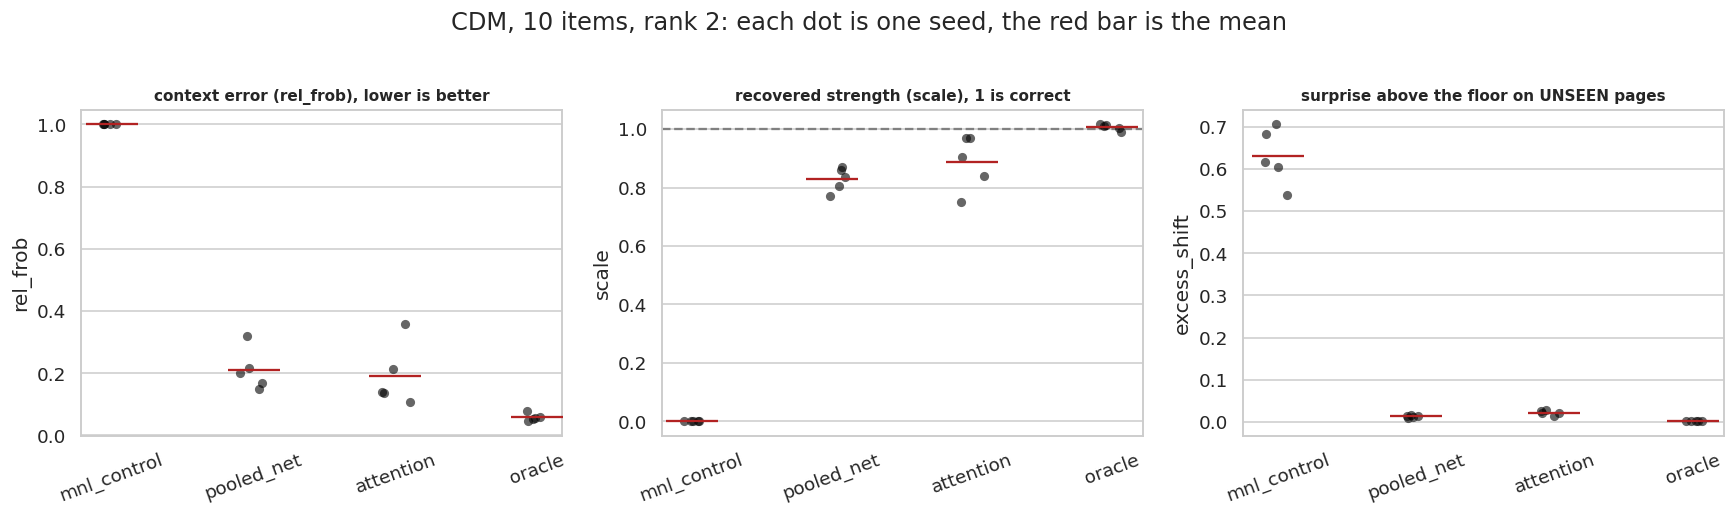

In [29]:
from scipy import stats

d = zoo_df.copy()
d["excess_in"] = d.eval_in - d.floor_in            # how far above the best possible surprise, in THIS world
d["excess_shift"] = d.eval_shift - d.floor_shift
d["shift_gap"] = d.eval_shift - d.eval_in
order = ["mnl_control", "pooled_net", "attention", "oracle"]

print("mean ± std over seeds\n")
cols = ["excess_in", "excess_shift", "shift_gap", "cosine", "rel_frob", "scale"]
summ = d.groupby("model")[cols].agg(["mean", "std"]).reindex(order)
print(summ.round(3).to_string())
print("\nbudget check (epochs used, best epoch):")
print(d.groupby("model")[["epochs", "best_epoch"]].agg(["min", "median", "max"]).reindex(order).to_string())


def paired_ci(df, a, b, metric):
    pa = df[df.model == a].set_index("seed")[metric]
    pb = df[df.model == b].set_index("seed")[metric]
    diff = (pa - pb).dropna()
    n = len(diff)
    half = stats.t.ppf(0.975, n - 1) * diff.std() / np.sqrt(n)
    return diff.mean(), diff.mean() - half, diff.mean() + half, n


print(f"\n{'A minus B':<26}{'metric':<14}{'mean':>8}{'95% CI':>22}   n")
for a, b in [("attention", "pooled_net"), ("attention", "oracle"), ("pooled_net", "oracle")]:
    for metric in ["rel_frob", "scale", "excess_in", "excess_shift"]:
        m, lo, hi, n = paired_ci(d, a, b, metric)
        print(f"{a + ' - ' + b:<26}{metric:<14}{m:>+8.4f}   [{lo:+.4f}, {hi:+.4f}]   {n}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (metric, title) in zip(axes, [("rel_frob", "context error (rel_frob), lower is better"),
                                      ("scale", "recovered strength (scale), 1 is correct"),
                                      ("excess_shift", "surprise above the floor on UNSEEN pages")]):
    sns.stripplot(data=d, x="model", y=metric, order=order, ax=ax, color="black", alpha=0.6, size=6)
    ax.scatter(np.arange(len(order)), d.groupby("model")[metric].mean().reindex(order).values,
               marker="_", s=1200, color="firebrick", zorder=3)
    if metric == "scale":
        ax.axhline(1.0, color="gray", linestyle="--")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("CDM, 10 items, rank 2: each dot is one seed, the red bar is the mean", y=1.02)
plt.tight_layout()
plt.show()

In [30]:
SWEEP_SIZES = [5000, 10000, 50000]          # 20,000 sessions is already done (Cell 24)
SWEEP_SEEDS = [101, 202, 303]
for m in SWEEP_SIZES:
    print(f"--- {m} training sessions ---")
    zoo_df = run_cdm_seeds_resumable(SWEEP_SEEDS, ZOO_CSV, n_train=m)
print()
print(zoo_df.groupby(["n_train", "model"]).seed.nunique().unstack())

--- 5000 training sessions ---
seed 101 saved (99s)
seed 202 saved (103s)
seed 303 saved (88s)
--- 10000 training sessions ---
seed 101 saved (209s)
seed 202 saved (200s)
seed 303 saved (192s)
--- 50000 training sessions ---
seed 101 saved (2737s)
seed 202 saved (1859s)
seed 303 saved (1919s)

model    attention  mnl_control  oracle  pooled_net
n_train                                            
5000             3            3       3           3
10000            3            3       3           3
20000            5            5       5           5
50000            3            3       3           3


context error (rel_frob), mean over seeds
model    mnl_control  pooled_net  attention  oracle
n_train                                            
5000             1.0       0.264      0.273   0.123
10000            1.0       0.252      0.238   0.089
20000            1.0       0.224      0.202   0.059
50000            1.0       0.194      0.160   0.041 

recovered strength (scale), mean over seeds
model    mnl_control  pooled_net  attention  oracle
n_train                                            
5000             0.0       0.826      0.820   1.005
10000            0.0       0.808      0.842   1.006
20000            0.0       0.826      0.875   1.011
50000            0.0       0.843      0.895   1.003 

surprise above the floor on seen pages
model    mnl_control  pooled_net  attention  oracle
n_train                                            
5000           0.632       0.029      0.038   0.007
10000          0.631       0.019      0.026   0.005
20000          0.631       0.010      0

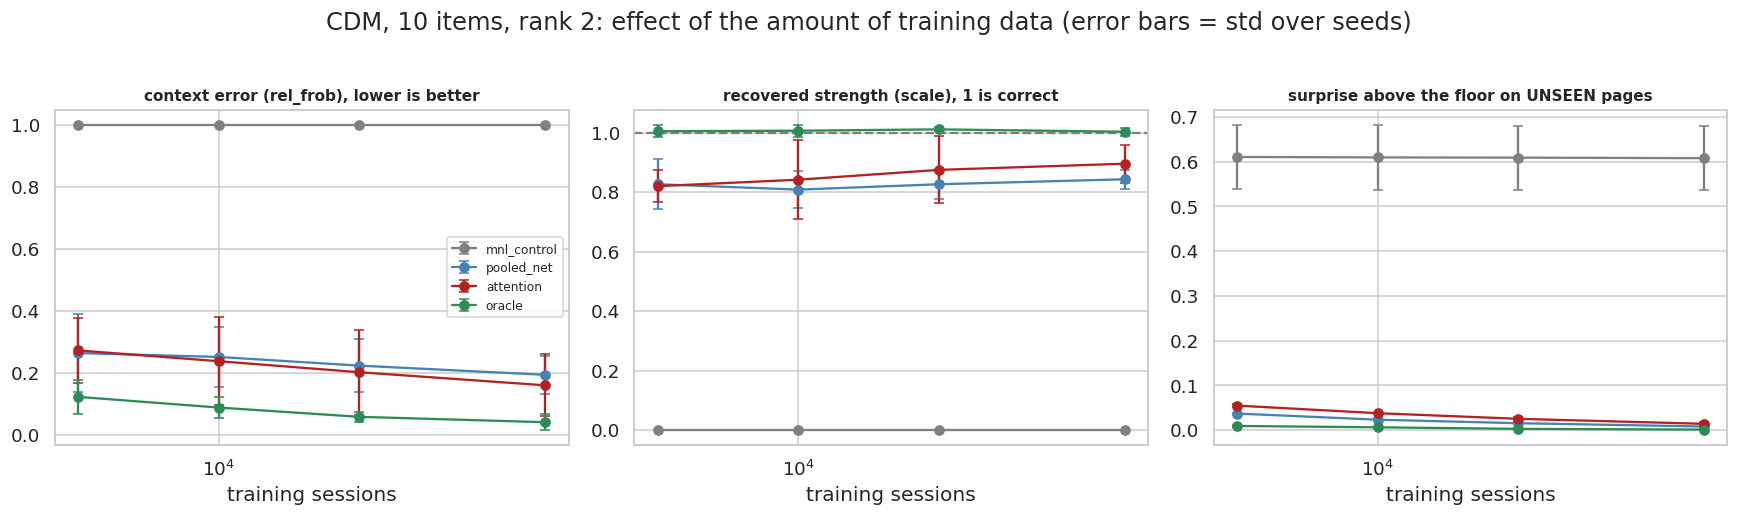

In [31]:
CDM_COLORS = {"mnl_control": "gray", "pooled_net": "steelblue", "attention": "firebrick", "oracle": "seagreen"}
sw = zoo_df[zoo_df.seed.isin(SWEEP_SEEDS)].copy()
sw["excess_in"] = sw.eval_in - sw.floor_in
sw["excess_shift"] = sw.eval_shift - sw.floor_shift
order = ["mnl_control", "pooled_net", "attention", "oracle"]

for metric, label in [("rel_frob", "context error (rel_frob), mean over seeds"),
                      ("scale", "recovered strength (scale), mean over seeds"),
                      ("excess_in", "surprise above the floor on seen pages"),
                      ("excess_shift", "surprise above the floor on UNSEEN pages")]:
    print(label)
    print(sw.pivot_table(index="n_train", columns="model", values=metric, aggfunc="mean")[order].round(3).to_string(), "\n")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (metric, title) in zip(axes, [("rel_frob", "context error (rel_frob), lower is better"),
                                      ("scale", "recovered strength (scale), 1 is correct"),
                                      ("excess_shift", "surprise above the floor on UNSEEN pages")]):
    for name in order:
        g = sw[sw.model == name].groupby("n_train")[metric].agg(["mean", "std"]).reset_index()
        ax.errorbar(g.n_train, g["mean"], yerr=g["std"].fillna(0), marker="o", capsize=3, label=name, color=CDM_COLORS[name])
    ax.set_xscale("log")
    ax.set_xlabel("training sessions")
    ax.set_title(title, fontsize=10)
axes[1].axhline(1.0, color="gray", linestyle="--")
axes[0].legend(fontsize=8)
plt.suptitle("CDM, 10 items, rank 2: effect of the amount of training data (error bars = std over seeds)", y=1.02)
plt.tight_layout()
plt.show()

In [32]:
print(f"{'rank':>5}{'avg P(top item)':>22}{'range':>16}{'pages top > 0.9 (%)':>24}{'true-U surprise':>22}")
for r in [1, 2, 3, 5, 10]:
    vals = []
    for s in range(30):
        U10 = pin_size(make_cdm_truth(N10, r, seed=s)[0])
        vals.append(decidedness(U10, PAGES10))
    v = np.array(vals)
    print(f"{r:>5}{v[:, 0].mean():>14.3f} ± {v[:, 0].std():.3f}"
          f"{v[:, 0].min():>9.3f}-{v[:, 0].max():.3f}"
          f"{v[:, 1].mean():>14.1f} ± {v[:, 1].std():.1f}"
          f"{v[:, 2].mean():>14.3f} ± {v[:, 2].std():.3f}")

 rank       avg P(top item)           range     pages top > 0.9 (%)       true-U surprise
    1         0.765 ± 0.068    0.610-0.895          38.7 ± 14.3         0.595 ± 0.163
    2         0.746 ± 0.059    0.634-0.897          32.8 ± 12.6         0.639 ± 0.142
    3         0.773 ± 0.047    0.686-0.881          37.5 ± 11.3         0.572 ± 0.118
    5         0.759 ± 0.042    0.691-0.867          34.2 ± 9.8         0.608 ± 0.104
   10         0.779 ± 0.029    0.737-0.873          37.4 ± 7.4         0.561 ± 0.072


In [33]:
RANK_LIST = [1, 3, 5, 10]            # rank 2 at 20,000 sessions is already done (Cell 24)
RANK_SEEDS = [101, 202, 303]
for r in RANK_LIST:
    print(f"--- rank {r} ---")
    zoo_df = run_cdm_seeds_resumable(RANK_SEEDS, ZOO_CSV, n_train=20000, rank=r)
print()
print(zoo_df[zoo_df.n_train == 20000].groupby(["rank", "model"]).seed.nunique().unstack())

--- rank 1 ---
seed 101 saved (557s)
seed 202 saved (908s)
seed 303 saved (775s)
--- rank 3 ---
seed 101 saved (699s)
seed 202 saved (725s)
seed 303 saved (593s)
--- rank 5 ---
seed 101 saved (708s)
seed 202 saved (747s)
seed 303 saved (741s)
--- rank 10 ---
seed 101 saved (670s)
seed 202 saved (807s)
seed 303 saved (723s)

model  attention  mnl_control  oracle  pooled_net
rank                                             
1              3            3       3           3
2              5            5       5           5
3              3            3       3           3
5              3            3       3           3
10             3            3       3           3


context error (rel_frob), mean over seeds
model  mnl_control  pooled_net  attention  oracle
rank                                             
1              1.0       0.254      0.319   0.078
2              1.0       0.224      0.202   0.059
3              1.0       0.249      0.230   0.080
5              1.0       0.261      0.316   0.096
10             1.0       0.219      0.289   0.069 

recovered strength (scale), mean over seeds
model  mnl_control  pooled_net  attention  oracle
rank                                             
1              0.0       0.807      0.789   1.002
2              0.0       0.826      0.875   1.011
3              0.0       0.809      0.864   0.996
5              0.0       0.824      0.812   0.991
10             0.0       0.841      0.875   1.009 

surprise above the floor on seen pages
model  mnl_control  pooled_net  attention  oracle
rank                                             
1            0.562       0.008      0.014   0.003
2            0.631   

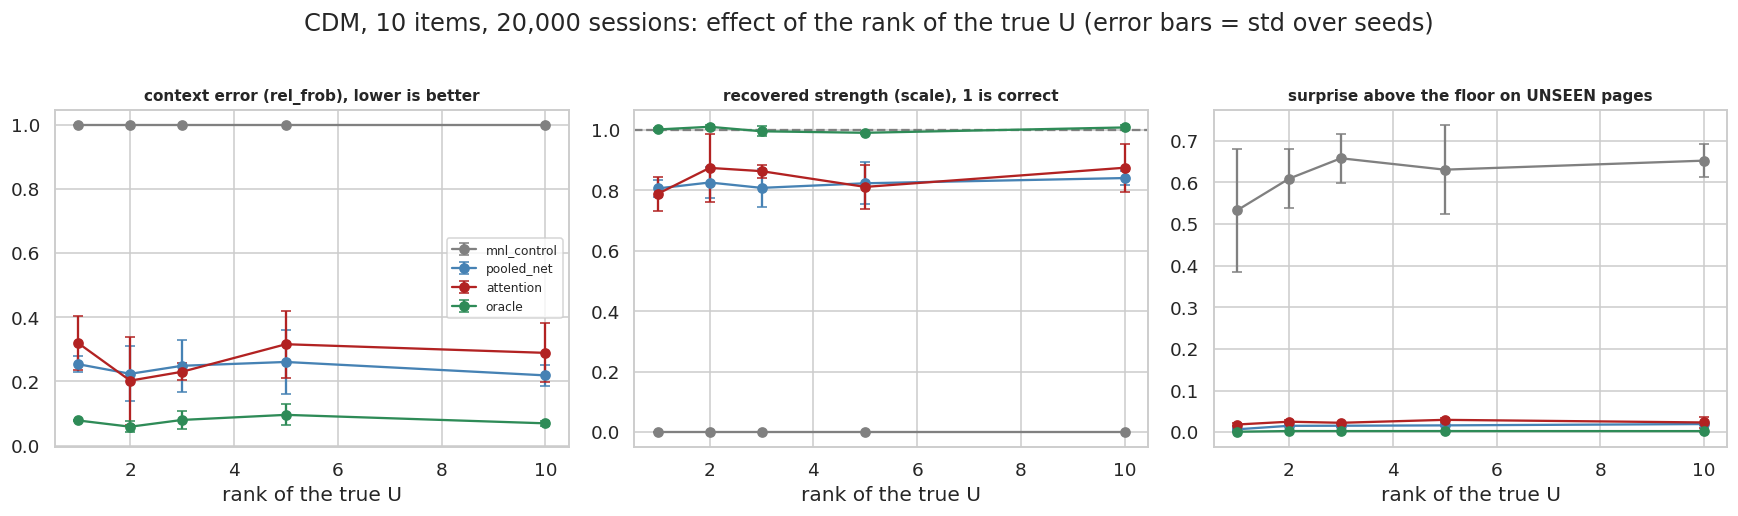

In [34]:
rk = zoo_df[(zoo_df.n_train == 20000) & zoo_df.seed.isin(RANK_SEEDS)].copy()
rk["excess_in"] = rk.eval_in - rk.floor_in
rk["excess_shift"] = rk.eval_shift - rk.floor_shift
order = ["mnl_control", "pooled_net", "attention", "oracle"]

for metric, label in [("rel_frob", "context error (rel_frob), mean over seeds"),
                      ("scale", "recovered strength (scale), mean over seeds"),
                      ("excess_in", "surprise above the floor on seen pages"),
                      ("excess_shift", "surprise above the floor on UNSEEN pages")]:
    print(label)
    print(rk.pivot_table(index="rank", columns="model", values=metric, aggfunc="mean")[order].round(3).to_string(), "\n")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (metric, title) in zip(axes, [("rel_frob", "context error (rel_frob), lower is better"),
                                      ("scale", "recovered strength (scale), 1 is correct"),
                                      ("excess_shift", "surprise above the floor on UNSEEN pages")]):
    for name in order:
        g = rk[rk.model == name].groupby("rank")[metric].agg(["mean", "std"]).reset_index()
        ax.errorbar(g["rank"], g["mean"], yerr=g["std"].fillna(0), marker="o", capsize=3, label=name, color=CDM_COLORS[name])
    ax.set_xlabel("rank of the true U")
    ax.set_title(title, fontsize=10)
axes[1].axhline(1.0, color="gray", linestyle="--")
axes[0].legend(fontsize=8)
plt.suptitle("CDM, 10 items, 20,000 sessions: effect of the rank of the true U (error bars = std over seeds)", y=1.02)
plt.tight_layout()
plt.show()

In [35]:
MORE_SEEDS = [404, 505]
for m in [5000, 10000, 50000]:
    print(f"--- {m} training sessions (rank 2) ---")
    zoo_df = run_cdm_seeds_resumable(MORE_SEEDS, ZOO_CSV, n_train=m)
for r in [1, 3, 5, 10]:
    print(f"--- rank {r} (20,000 sessions) ---")
    zoo_df = run_cdm_seeds_resumable(MORE_SEEDS, ZOO_CSV, n_train=20000, rank=r)
print()
print(zoo_df.groupby(["rank", "n_train", "model"]).seed.nunique().unstack())

--- 5000 training sessions (rank 2) ---
seed 404 saved (102s)
seed 505 saved (94s)
--- 10000 training sessions (rank 2) ---
seed 404 saved (198s)
seed 505 saved (206s)
--- 50000 training sessions (rank 2) ---
seed 404 saved (1818s)
seed 505 saved (2474s)
--- rank 1 (20,000 sessions) ---
seed 404 saved (585s)
seed 505 saved (587s)
--- rank 3 (20,000 sessions) ---
seed 404 saved (753s)
seed 505 saved (596s)
--- rank 5 (20,000 sessions) ---
seed 404 saved (679s)
seed 505 saved (949s)
--- rank 10 (20,000 sessions) ---
seed 404 saved (823s)
seed 505 saved (577s)

model         attention  mnl_control  oracle  pooled_net
rank n_train                                            
1    20000            5            5       5           5
2    5000             5            5       5           5
     10000            5            5       5           5
     20000            5            5       5           5
     50000            5            5       5           5
3    20000            5            5

In [36]:
from scipy import stats

d = zoo_df.copy()
d["excess_in"] = d.eval_in - d.floor_in
d["excess_shift"] = d.eval_shift - d.floor_shift


def paired_ci_by(df, a, b, metric):
    """Mean of (a - b) over seeds with a 95% interval; both models share the same worlds, so this is a paired comparison."""
    pa = df[df.model == a].set_index("seed")[metric]
    pb = df[df.model == b].set_index("seed")[metric]
    diff = (pa - pb).dropna()
    n = len(diff)
    if n < 2:
        return np.nan, np.nan, np.nan, n
    half = stats.t.ppf(0.975, n - 1) * diff.std() / np.sqrt(n)
    return diff.mean(), diff.mean() - half, diff.mean() + half, n


rows = []
for (rank_, n_train_), g in d.groupby(["rank", "n_train"]):
    for a, b in [("attention", "pooled_net"), ("attention", "oracle")]:
        for metric in ["rel_frob", "scale", "excess_shift"]:
            m, lo, hi, n = paired_ci_by(g, a, b, metric)
            rows.append(dict(rank=rank_, n_train=n_train_, comparison=f"{a} - {b}", metric=metric,
                             mean=m, lo=lo, hi=hi, n=n, sig=bool(lo > 0 or hi < 0)))
ci = pd.DataFrame(rows)


def fmt(r):
    return f"{r['mean']:+.3f} [{r['lo']:+.3f}, {r['hi']:+.3f}]" + (" *" if r["sig"] else "")


for comp in ["attention - pooled_net", "attention - oracle"]:
    sub = ci[ci.comparison == comp].copy()
    sub["txt"] = sub.apply(fmt, axis=1)
    tab = sub.pivot_table(index=["rank", "n_train"], columns="metric", values="txt", aggfunc="first")
    tab["seeds"] = sub.groupby(["rank", "n_train"])["n"].first()
    print(f"\n{comp}    (* = the 95% interval excludes zero)")
    print(tab.to_string())


attention - pooled_net    (* = the 95% interval excludes zero)
metric                     excess_shift                   rel_frob                      scale  seeds
rank n_train                                                                                        
1    20000    +0.012 [+0.006, +0.018] *  +0.063 [+0.010, +0.117] *    +0.000 [-0.072, +0.073]      5
2    5000     +0.020 [+0.007, +0.033] *    +0.025 [-0.014, +0.065]    +0.000 [-0.064, +0.065]      5
     10000    +0.014 [+0.005, +0.023] *    -0.008 [-0.057, +0.041]    +0.042 [-0.045, +0.128]      5
     20000    +0.009 [+0.006, +0.012] *    -0.020 [-0.069, +0.030]    +0.058 [-0.008, +0.124]      5
     50000    +0.006 [+0.002, +0.011] *    -0.030 [-0.073, +0.012]  +0.064 [+0.002, +0.125] *      5
3    20000    +0.008 [+0.005, +0.012] *    +0.019 [-0.063, +0.101]    +0.045 [-0.031, +0.120]      5
5    20000    +0.015 [+0.009, +0.022] *    +0.018 [-0.047, +0.083]    +0.027 [-0.048, +0.102]      5
10   20000      +0.007 [-0.